# 🌾 Seasonal Agriculture Performance Analysis

### Major Project - VOIS AICTE Batch 1 2026-2027

**Objective:**  
To analyze agricultural performance across different seasons and identify
patterns, trends, relationships, variations and significant differences
in agricultural activities.

**Tools Used:**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SciPy
- Google Colab

**Dataset:** Seasonal Agriculture Performance Dataset

In [1]:
# ==========================================
# IMPORT REQUIRED LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import f_oneway, kruskal, pearsonr, spearmanr

import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Visualization settings
sns.set_theme(style="whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset (1).csv


In [3]:
import io

filename = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("Dataset loaded successfully!")
print("File name:", filename)

Dataset loaded successfully!
File name: seasonal_agriculture_performance_dataset (1).csv


In [4]:
print("FIRST 5 ROWS")
display(df.head())

FIRST 5 ROWS


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [5]:
print("LAST 5 ROWS")
display(df.tail())

LAST 5 ROWS


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,7.97,27.3,104.3,44.8,94.0,Drip,271.1,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,6.57,33.7,127.8,44.9,91.3,Drip,176.6,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,7.25,21.1,126.7,59.9,148.0,Drip,234.7,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,6.11,30.5,107.5,20.7,91.0,Sprinkler,329.7,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,6.16,35.7,137.1,92.6,145.5,Sprinkler,205.9,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [6]:
rows, columns = df.shape

print("Number of Rows:", rows)
print("Number of Columns:", columns)

Number of Rows: 4000
Number of Columns: 28


In [7]:
print("Dataset Columns:")
for i, column in enumerate(df.columns, start=1):
    print(i, ".", column)

Dataset Columns:
1 . Farm_ID
2 . State
3 . District
4 . Crop
5 . Season
6 . Farm_Area_Hectares
7 . Rainfall_mm
8 . Avg_Temperature_C
9 . Humidity_pct
10 . Sunlight_Hours_Day
11 . Soil_pH
12 . Soil_Moisture_pct
13 . Nitrogen_kg_ha
14 . Phosphorus_kg_ha
15 . Potassium_kg_ha
16 . Irrigation_Method
17 . Fertilizer_kg_ha
18 . Pesticide_Litre_ha
19 . Seed_Quality_Score
20 . Yield_Tonnes_Ha
21 . Production_Tonnes
22 . Market_Price_INR_Tonne
23 . Total_Cost_INR
24 . Revenue_INR
25 . Profit_INR
26 . Water_Used_m3
27 . Water_Efficiency_t_per_1000m3
28 . Disease_Pest_Risk_pct


In [8]:
print("DATA TYPES")
display(df.dtypes)

DATA TYPES


,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [9]:
print("DATASET INFORMATION")
df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha              

In [10]:
missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Values': missing_values.values,
    'Missing Percentage':
        (missing_values.values / len(df)) * 100
})

display(
    missing_table[
        missing_table['Missing Values'] > 0
    ].sort_values(
        'Missing Values',
        ascending=False
    )
)

,Column,Missing Values,Missing Percentage
6,Rainfall_mm,48,1.2
11,Soil_Moisture_pct,40,1.0
19,Yield_Tonnes_Ha,32,0.8


In [11]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [12]:
print("STATISTICAL SUMMARY")

display(df.describe().T)

STATISTICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [13]:
categorical_columns = df.select_dtypes(
    include='object'
).columns

for column in categorical_columns:
    print("\n", "="*60)
    print(column)
    print("="*60)
    print(df[column].value_counts())


Farm_ID
Farm_ID
SF13984    1
SF13983    1
SF13982    1
SF13981    1
SF13980    1
          ..
SF10005    1
SF10004    1
SF10003    1
SF10002    1
SF10001    1
Name: count, Length: 4000, dtype: int64

State
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

District
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

Crop
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Season
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Irrigation_Method
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count,

In [14]:
print("Unique Seasons:")
print(df['Season'].unique())

print("\nSeason Counts:")
print(df['Season'].value_counts())

Unique Seasons:
['Kharif' 'Rabi' 'Zaid']

Season Counts:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


In [15]:
# Create a copy of original dataset
df_clean = df.copy()

# Numerical columns
numeric_columns = df_clean.select_dtypes(
    include=np.number
).columns

# Fill numerical missing values with median
for column in numeric_columns:
    if df_clean[column].isnull().sum() > 0:
        df_clean[column] = df_clean[column].fillna(
            df_clean[column].median()
        )

print("Missing numerical values handled successfully.")

Missing numerical values handled successfully.


In [16]:
print("Remaining Missing Values:")

display(
    df_clean.isnull().sum()[
        df_clean.isnull().sum() > 0
    ]
)

Remaining Missing Values:


,0


In [17]:
df_clean = df_clean.drop_duplicates()

print("Dataset shape after cleaning:", df_clean.shape)

Dataset shape after cleaning: (4000, 28)


In [18]:
# Profit Margin
df_clean['Profit_Margin_pct'] = np.where(
    df_clean['Revenue_INR'] != 0,
    (df_clean['Profit_INR'] /
     df_clean['Revenue_INR']) * 100,
    0
)

# Cost per hectare
df_clean['Cost_per_Hectare'] = np.where(
    df_clean['Farm_Area_Hectares'] != 0,
    df_clean['Total_Cost_INR'] /
    df_clean['Farm_Area_Hectares'],
    0
)

# Revenue per hectare
df_clean['Revenue_per_Hectare'] = np.where(
    df_clean['Farm_Area_Hectares'] != 0,
    df_clean['Revenue_INR'] /
    df_clean['Farm_Area_Hectares'],
    0
)

# Profit per hectare
df_clean['Profit_per_Hectare'] = np.where(
    df_clean['Farm_Area_Hectares'] != 0,
    df_clean['Profit_INR'] /
    df_clean['Farm_Area_Hectares'],
    0
)

print("Derived variables created successfully!")

Derived variables created successfully!


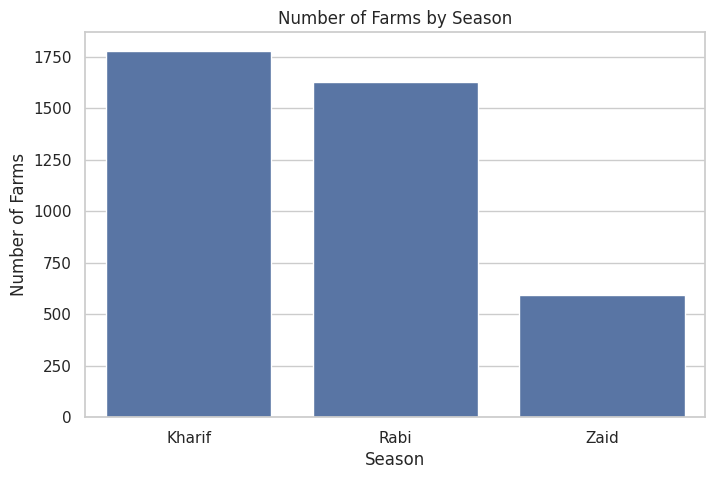

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x='Season'
)

plt.title('Number of Farms by Season')
plt.xlabel('Season')
plt.ylabel('Number of Farms')

plt.show()

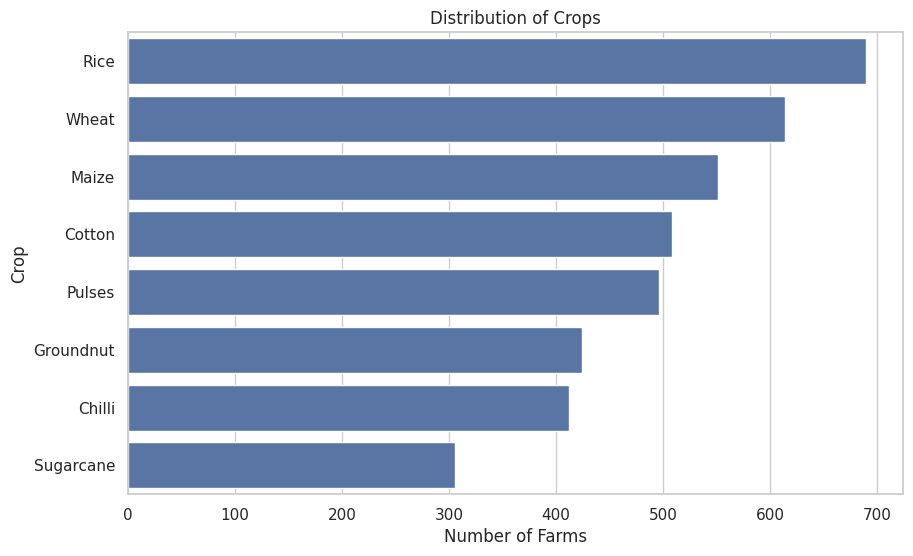

In [20]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df_clean,
    y='Crop',
    order=df_clean['Crop'].value_counts().index
)

plt.title('Distribution of Crops')
plt.xlabel('Number of Farms')
plt.ylabel('Crop')

plt.show()

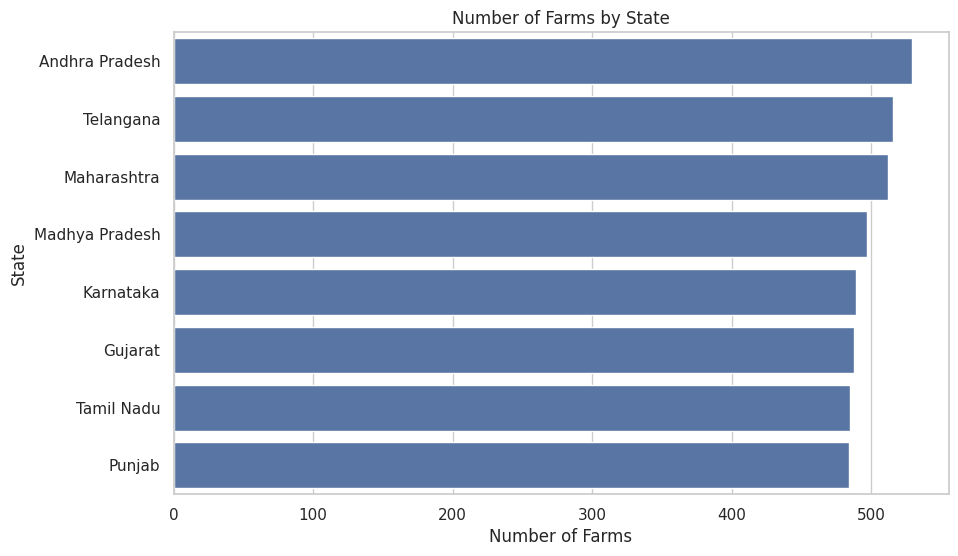

In [21]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df_clean,
    y='State',
    order=df_clean['State'].value_counts().index
)

plt.title('Number of Farms by State')
plt.xlabel('Number of Farms')
plt.ylabel('State')

plt.show()

In [22]:
season_summary = df_clean.groupby('Season').agg({

    'Yield_Tonnes_Ha': ['mean', 'median'],
    'Production_Tonnes': ['mean', 'median'],
    'Revenue_INR': ['mean', 'median'],
    'Total_Cost_INR': ['mean', 'median'],
    'Profit_INR': ['mean', 'median'],
    'Water_Used_m3': ['mean', 'median'],
    'Water_Efficiency_t_per_1000m3': ['mean', 'median'],
    'Disease_Pest_Risk_pct': ['mean', 'median']

}).round(2)

display(season_summary)

Yield_Tonnes_Ha        Production_Tonnes        Revenue_INR            \
                  mean median              mean median        mean    median   
Season                                                                         
Kharif            5.63   1.94             46.31  13.24   710719.06  520196.0   
Rabi              5.04   1.67             41.49  11.08   601526.05  438156.0   
Zaid              4.64   1.46             38.89   9.97   519171.90  373700.5   

       Total_Cost_INR           Profit_INR          Water_Used_m3          \
                 mean    median       mean   median          mean  median   
Season                                                                      
Kharif      531804.41  524840.0  178914.65  38808.0       6102.20  4469.0   
Rabi        513836.58  506733.0   87689.47  -3187.0       5846.99  4292.0   
Zaid        543976.73  534833.0  -24804.82 -62144.0       6419.89  4805.0   

       Water_Efficiency_t_per_1000m3        Disease_Pest_Risk_pct         
                                mean median                  mean median  
Season                                                                    
Kharif                          5.89   3.28                 54.47   54.5  
Rabi                            5.19   2.74                 40.48   40.6  
Zaid                            4.41   2.30                 38.22   37.9

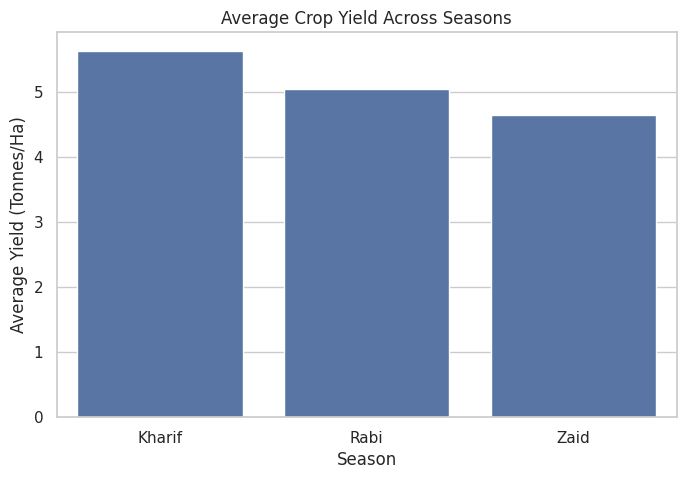

In [23]:
season_yield = df_clean.groupby(
    'Season'
)['Yield_Tonnes_Ha'].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=season_yield.index,
    y=season_yield.values
)

plt.title('Average Crop Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')

plt.show()

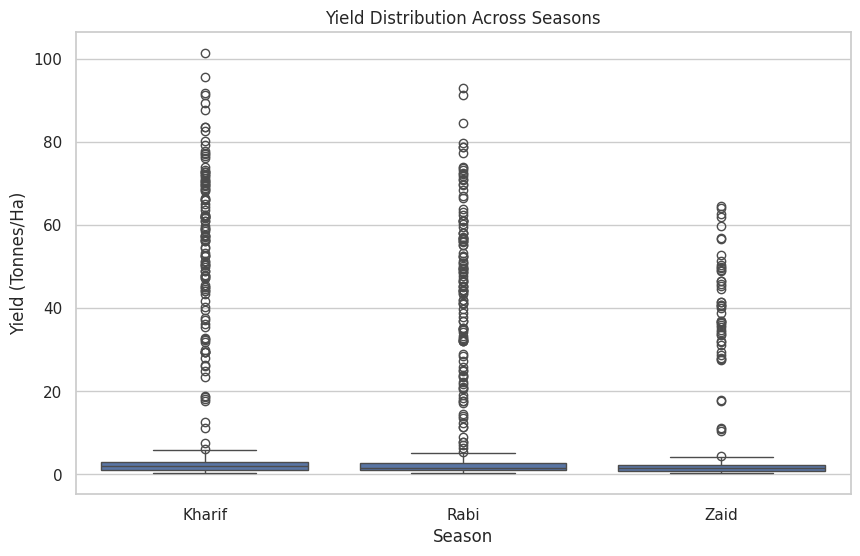

In [24]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_clean,
    x='Season',
    y='Yield_Tonnes_Ha'
)

plt.title('Yield Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

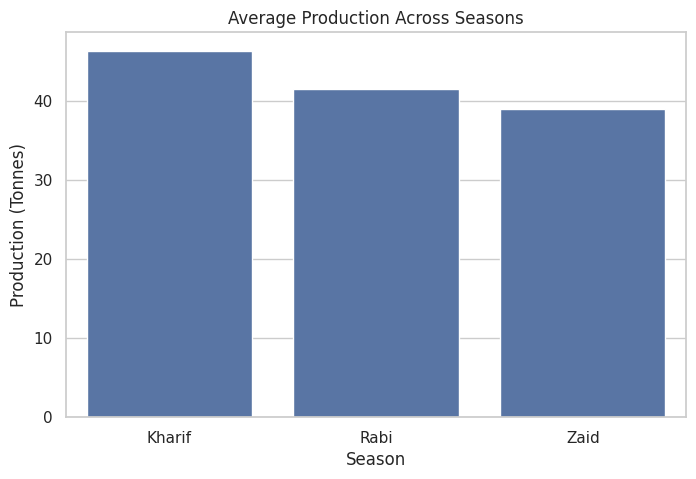

In [25]:
production = df_clean.groupby(
    'Season'
)['Production_Tonnes'].mean()

plt.figure(figsize=(8,5))

sns.barplot(
    x=production.index,
    y=production.values
)

plt.title('Average Production Across Seasons')
plt.xlabel('Season')
plt.ylabel('Production (Tonnes)')

plt.show()

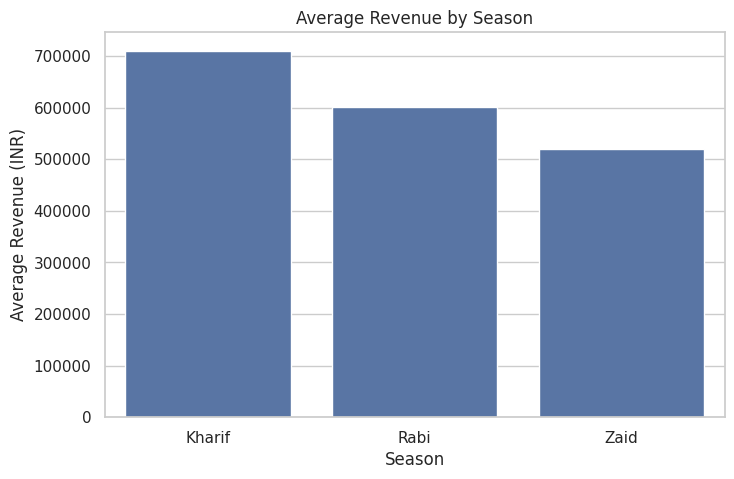

In [26]:
revenue = df_clean.groupby(
    'Season'
)['Revenue_INR'].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=revenue.index,
    y=revenue.values
)

plt.title('Average Revenue by Season')
plt.xlabel('Season')
plt.ylabel('Average Revenue (INR)')

plt.ticklabel_format(
    style='plain',
    axis='y'
)

plt.show()

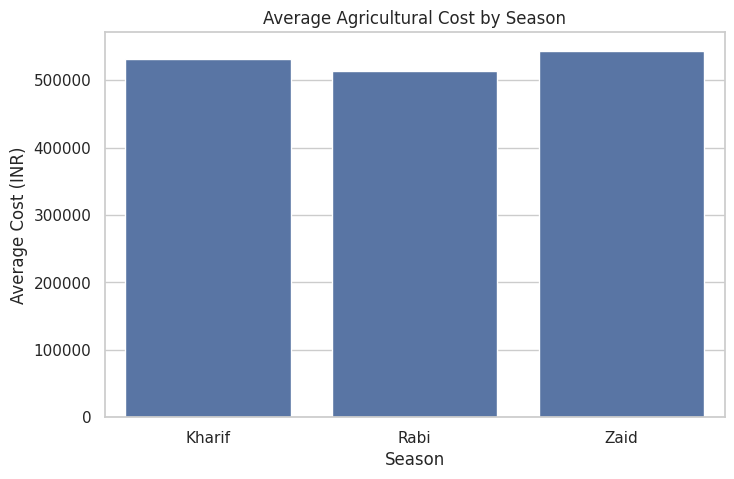

In [27]:
cost = df_clean.groupby(
    'Season'
)['Total_Cost_INR'].mean()

plt.figure(figsize=(8,5))

sns.barplot(
    x=cost.index,
    y=cost.values
)

plt.title('Average Agricultural Cost by Season')
plt.xlabel('Season')
plt.ylabel('Average Cost (INR)')

plt.ticklabel_format(
    style='plain',
    axis='y'
)

plt.show()

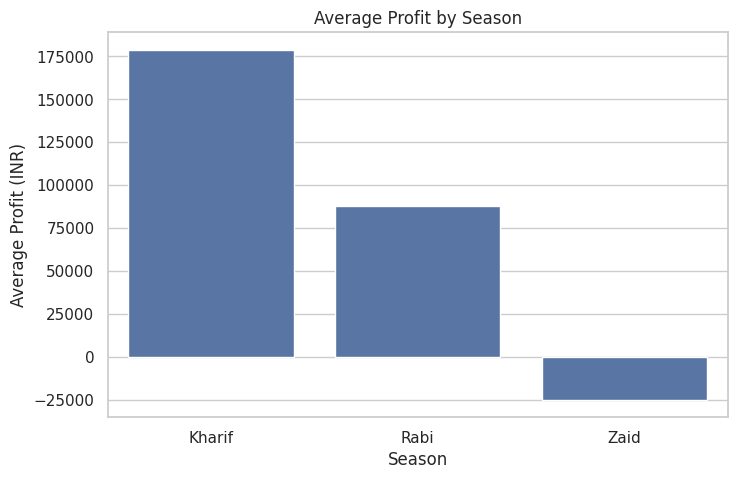

In [28]:
profit = df_clean.groupby(
    'Season'
)['Profit_INR'].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=profit.index,
    y=profit.values
)

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')

plt.ticklabel_format(
    style='plain',
    axis='y'
)

plt.show()

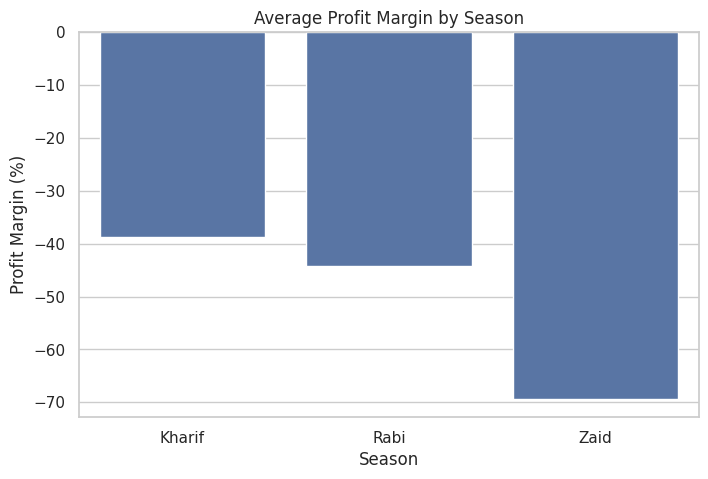

In [29]:
profit_margin = df_clean.groupby(
    'Season'
)['Profit_Margin_pct'].mean()

plt.figure(figsize=(8,5))

sns.barplot(
    x=profit_margin.index,
    y=profit_margin.values
)

plt.title('Average Profit Margin by Season')
plt.xlabel('Season')
plt.ylabel('Profit Margin (%)')

plt.show()

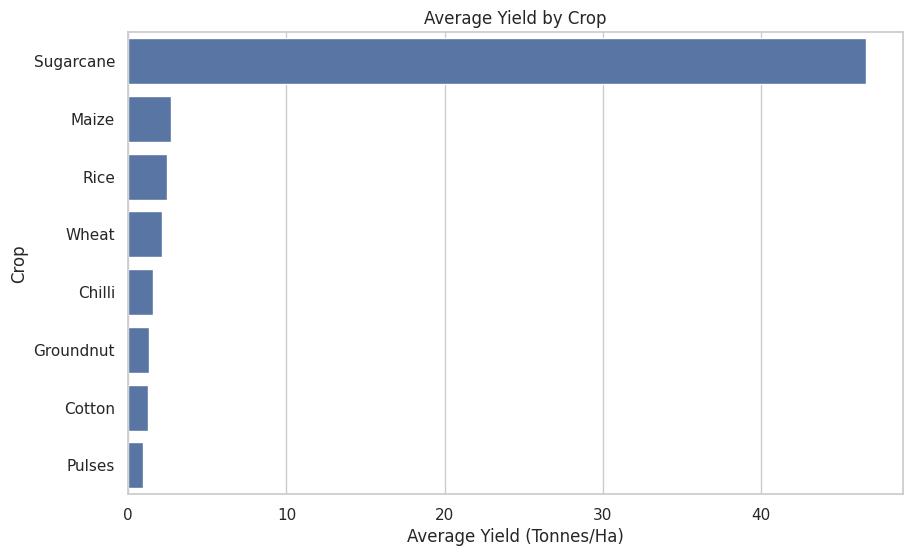

In [30]:
crop_yield = df_clean.groupby(
    'Crop'
)['Yield_Tonnes_Ha'].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=crop_yield.values,
    y=crop_yield.index
)

plt.title('Average Yield by Crop')
plt.xlabel('Average Yield (Tonnes/Ha)')
plt.ylabel('Crop')

plt.show()

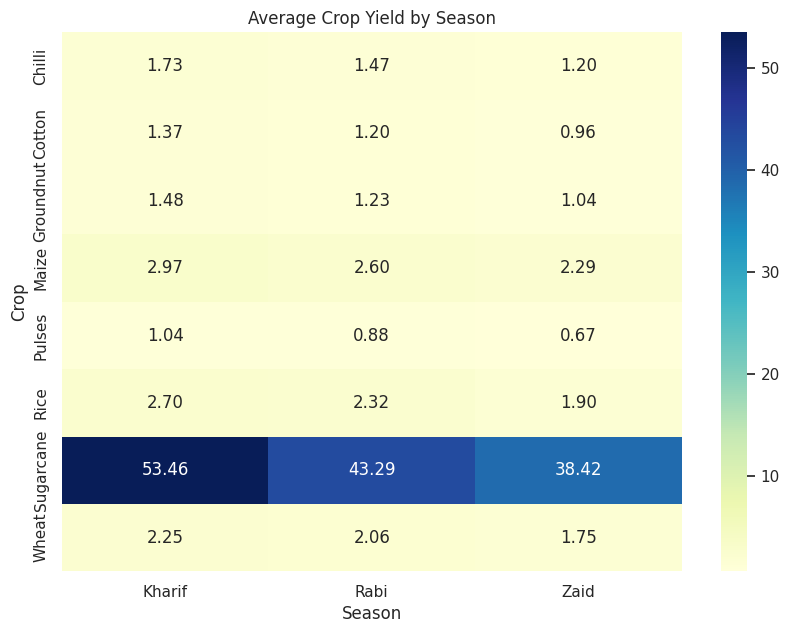

In [31]:
crop_season_yield = pd.pivot_table(
    df_clean,
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

plt.figure(figsize=(10,7))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Average Crop Yield by Season')
plt.xlabel('Season')
plt.ylabel('Crop')

plt.show()

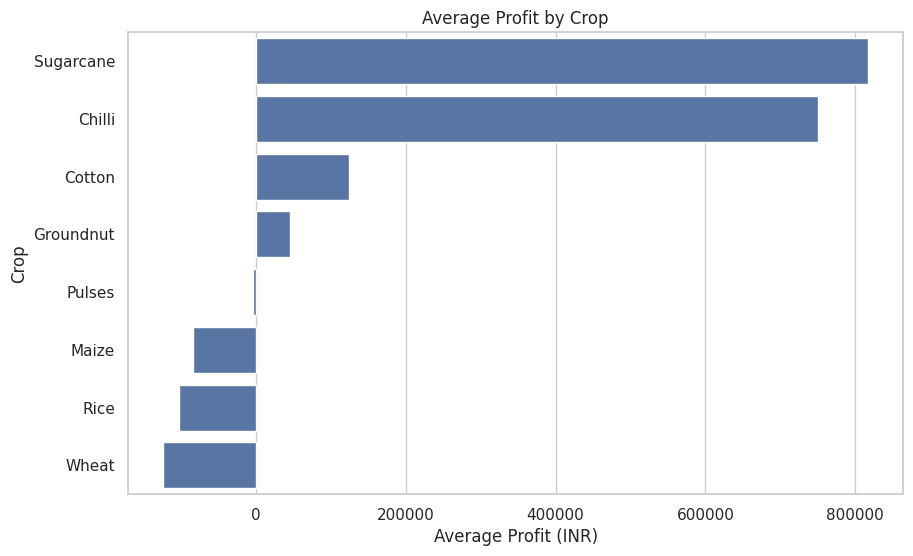

In [32]:
crop_profit = df_clean.groupby(
    'Crop'
)['Profit_INR'].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=crop_profit.values,
    y=crop_profit.index
)

plt.title('Average Profit by Crop')
plt.xlabel('Average Profit (INR)')
plt.ylabel('Crop')

plt.ticklabel_format(
    style='plain',
    axis='x'
)

plt.show()

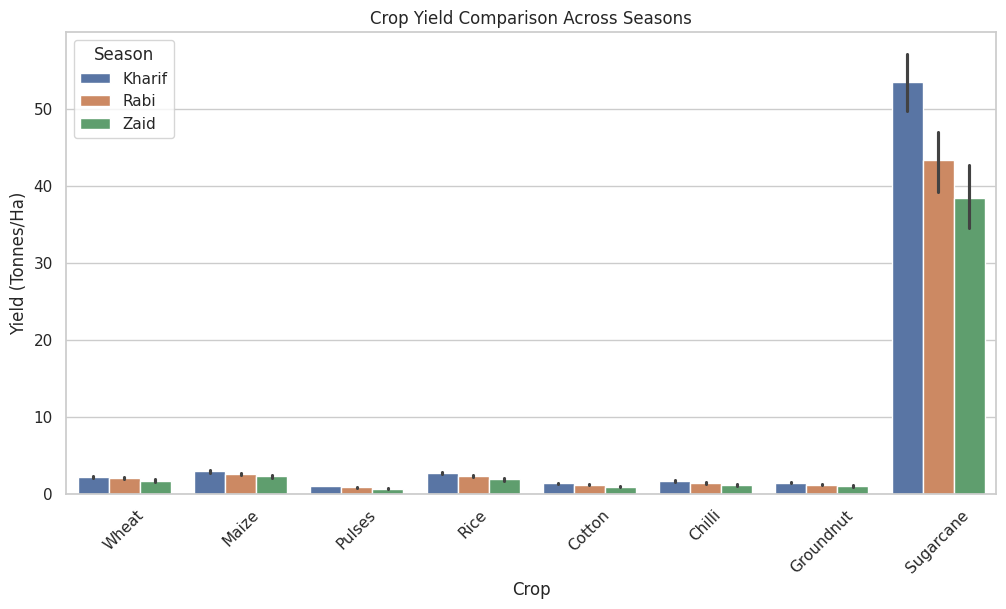

In [33]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df_clean,
    x='Crop',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Crop Yield Comparison Across Seasons')
plt.xlabel('Crop')
plt.ylabel('Yield (Tonnes/Ha)')

plt.xticks(rotation=45)

plt.show()

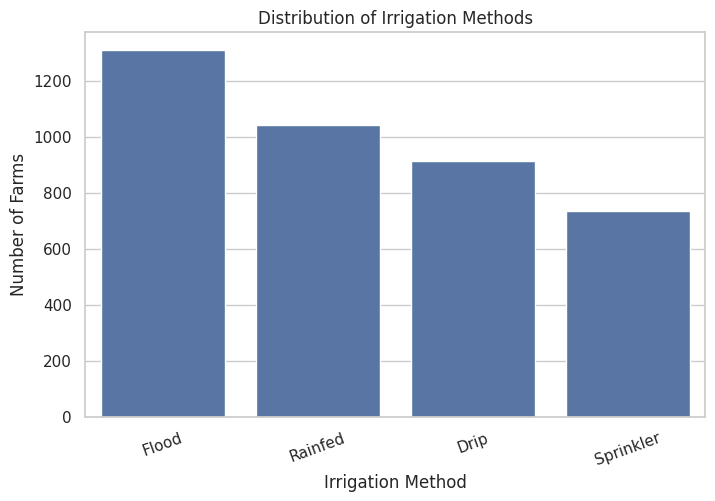

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x='Irrigation_Method',
    order=df_clean['Irrigation_Method'].value_counts().index
)

plt.title('Distribution of Irrigation Methods')
plt.xlabel('Irrigation Method')
plt.ylabel('Number of Farms')

plt.xticks(rotation=20)

plt.show()

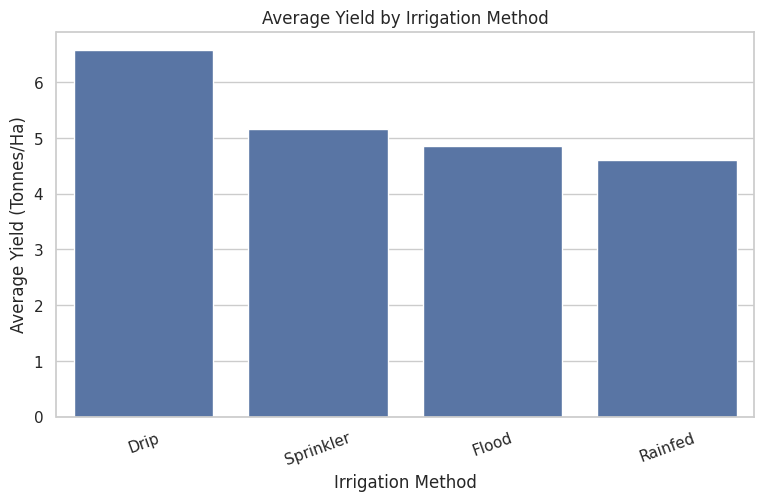

In [35]:
irrigation_yield = df_clean.groupby(
    'Irrigation_Method'
)['Yield_Tonnes_Ha'].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(9,5))

sns.barplot(
    x=irrigation_yield.index,
    y=irrigation_yield.values
)

plt.title('Average Yield by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Average Yield (Tonnes/Ha)')

plt.xticks(rotation=20)

plt.show()

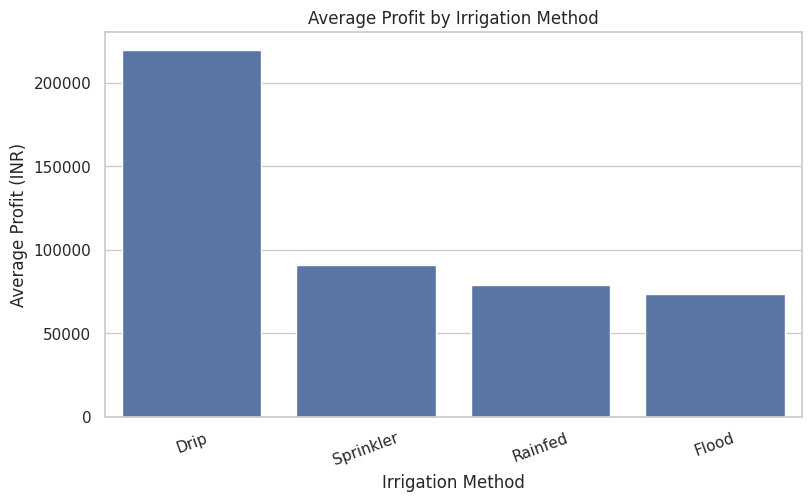

In [36]:
irrigation_profit = df_clean.groupby(
    'Irrigation_Method'
)['Profit_INR'].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(9,5))

sns.barplot(
    x=irrigation_profit.index,
    y=irrigation_profit.values
)

plt.title('Average Profit by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Average Profit (INR)')

plt.xticks(rotation=20)

plt.show()

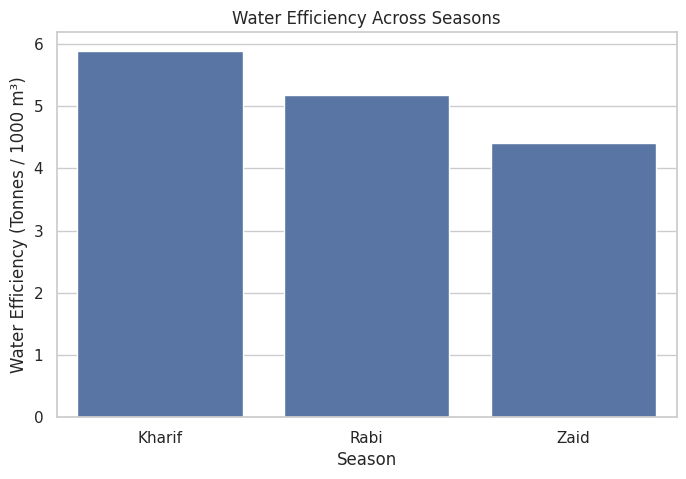

In [37]:
water_efficiency = df_clean.groupby(
    'Season'
)['Water_Efficiency_t_per_1000m3'].mean()

plt.figure(figsize=(8,5))

sns.barplot(
    x=water_efficiency.index,
    y=water_efficiency.values
)

plt.title('Water Efficiency Across Seasons')
plt.xlabel('Season')
plt.ylabel('Water Efficiency (Tonnes / 1000 m³)')

plt.show()

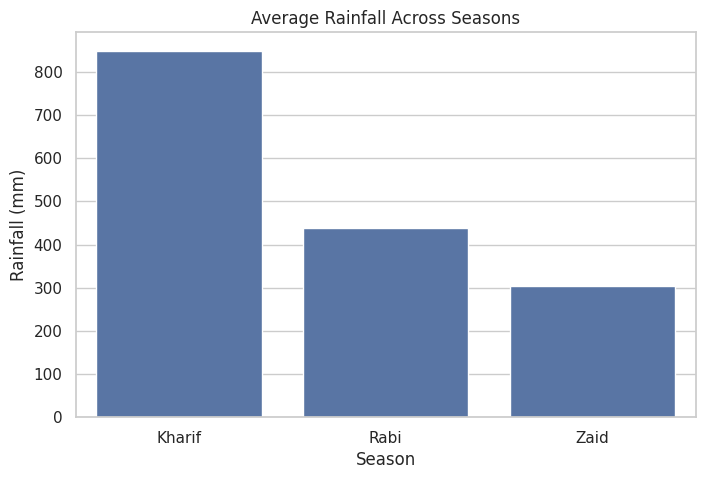

In [38]:
rainfall = df_clean.groupby(
    'Season'
)['Rainfall_mm'].mean()

plt.figure(figsize=(8,5))

sns.barplot(
    x=rainfall.index,
    y=rainfall.values
)

plt.title('Average Rainfall Across Seasons')
plt.xlabel('Season')
plt.ylabel('Rainfall (mm)')

plt.show()

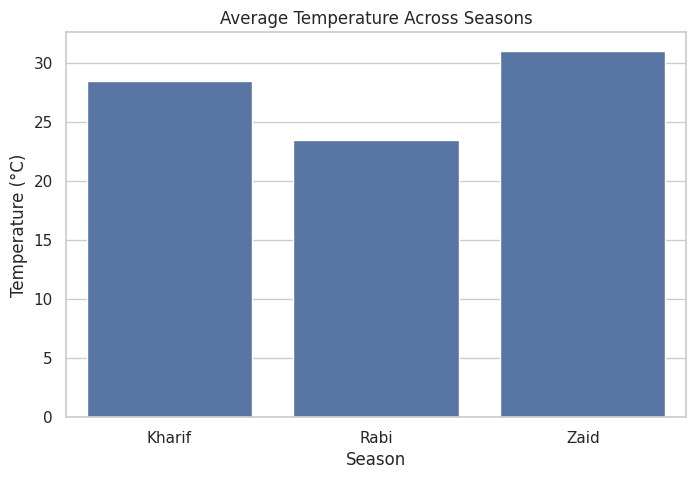

In [39]:
temperature = df_clean.groupby(
    'Season'
)['Avg_Temperature_C'].mean()

plt.figure(figsize=(8,5))

sns.barplot(
    x=temperature.index,
    y=temperature.values
)

plt.title('Average Temperature Across Seasons')
plt.xlabel('Season')
plt.ylabel('Temperature (°C)')

plt.show()

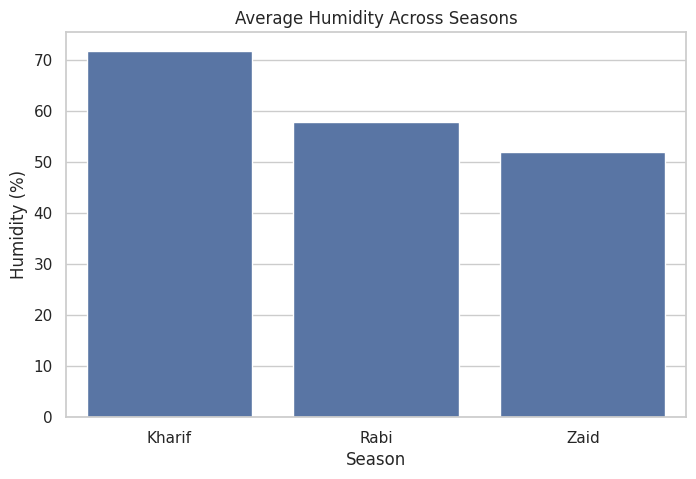

In [40]:
humidity = df_clean.groupby(
    'Season'
)['Humidity_pct'].mean()

plt.figure(figsize=(8,5))

sns.barplot(
    x=humidity.index,
    y=humidity.values
)

plt.title('Average Humidity Across Seasons')
plt.xlabel('Season')
plt.ylabel('Humidity (%)')

plt.show()

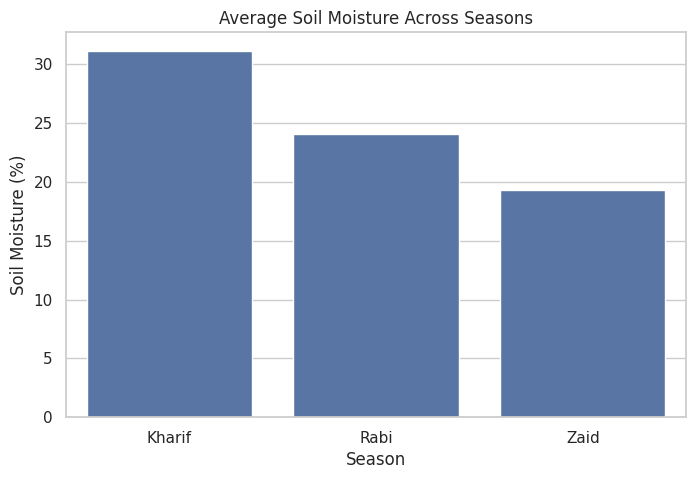

In [41]:
soil_moisture = df_clean.groupby(
    'Season'
)['Soil_Moisture_pct'].mean()

plt.figure(figsize=(8,5))

sns.barplot(
    x=soil_moisture.index,
    y=soil_moisture.values
)

plt.title('Average Soil Moisture Across Seasons')
plt.xlabel('Season')
plt.ylabel('Soil Moisture (%)')

plt.show()

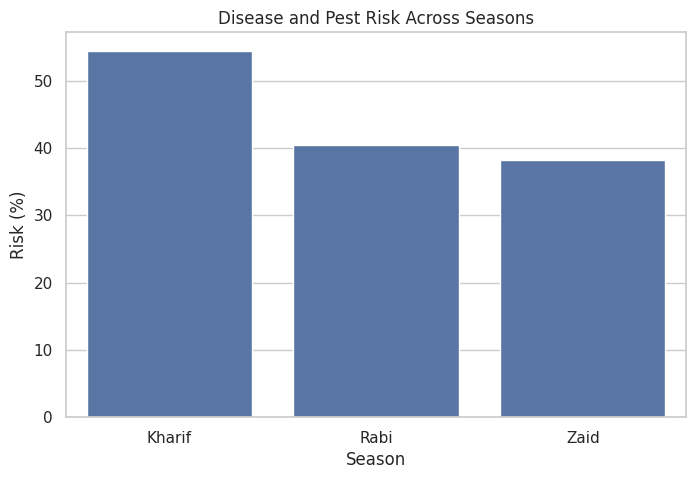

In [42]:
risk = df_clean.groupby(
    'Season'
)['Disease_Pest_Risk_pct'].mean()

plt.figure(figsize=(8,5))

sns.barplot(
    x=risk.index,
    y=risk.values
)

plt.title('Disease and Pest Risk Across Seasons')
plt.xlabel('Season')
plt.ylabel('Risk (%)')

plt.show()

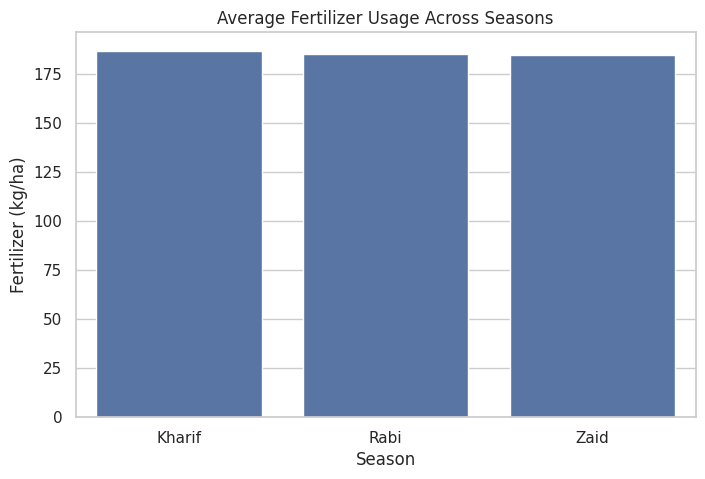

In [43]:
fertilizer = df_clean.groupby(
    'Season'
)['Fertilizer_kg_ha'].mean()

plt.figure(figsize=(8,5))

sns.barplot(
    x=fertilizer.index,
    y=fertilizer.values
)

plt.title('Average Fertilizer Usage Across Seasons')
plt.xlabel('Season')
plt.ylabel('Fertilizer (kg/ha)')

plt.show()

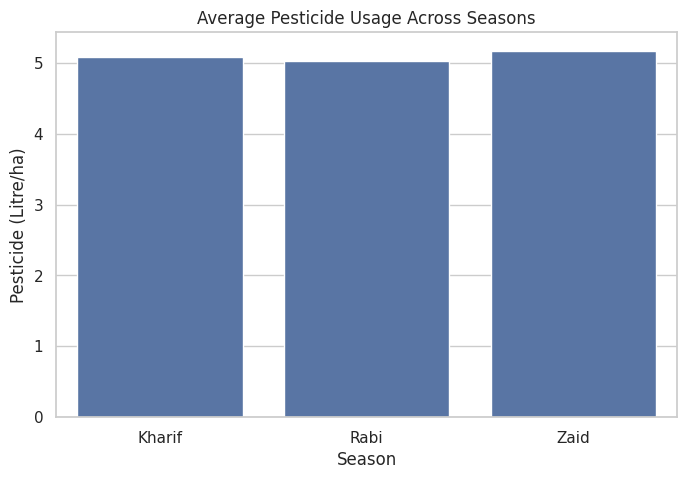

In [44]:
pesticide = df_clean.groupby(
    'Season'
)['Pesticide_Litre_ha'].mean()

plt.figure(figsize=(8,5))

sns.barplot(
    x=pesticide.index,
    y=pesticide.values
)

plt.title('Average Pesticide Usage Across Seasons')
plt.xlabel('Season')
plt.ylabel('Pesticide (Litre/ha)')

plt.show()

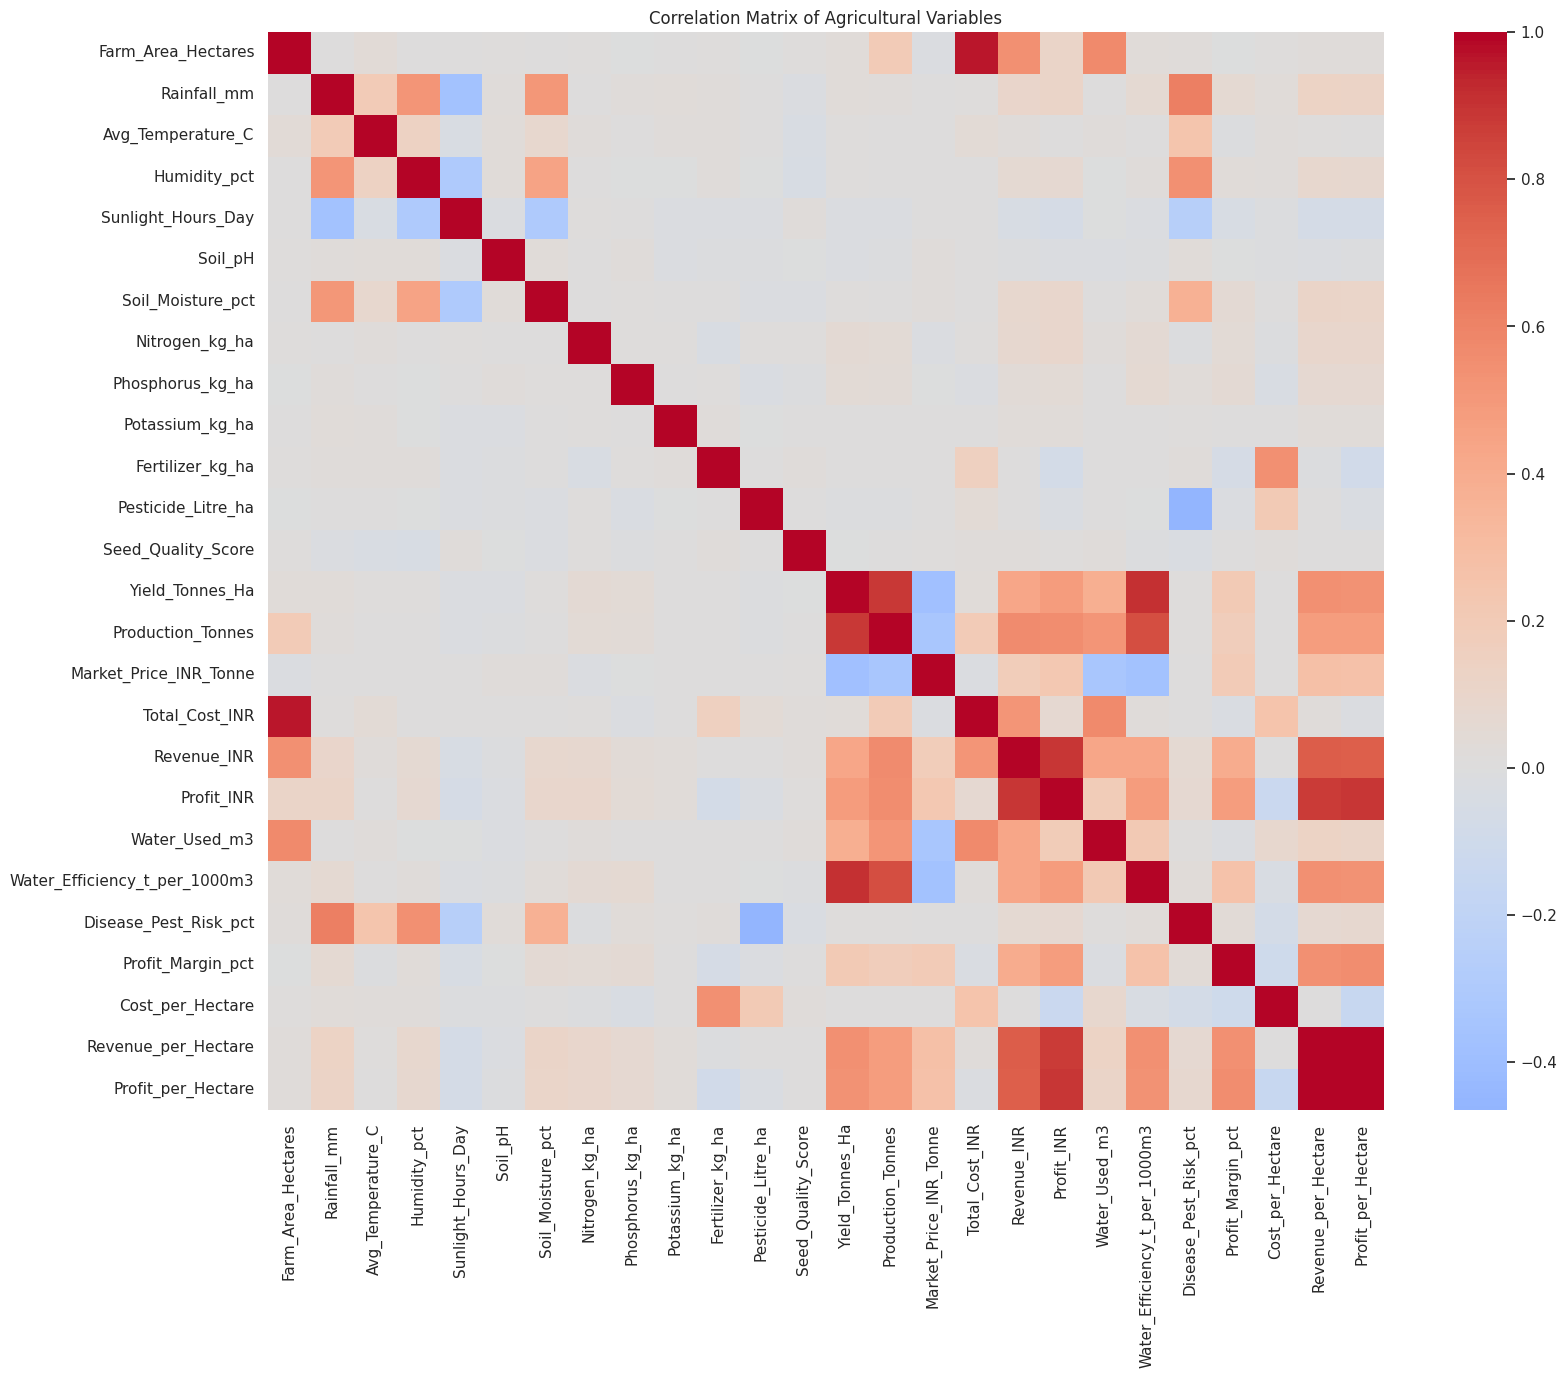

In [45]:
numeric_df = df_clean.select_dtypes(
    include=np.number
)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(18,14))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0,
    annot=False
)

plt.title('Correlation Matrix of Agricultural Variables')

plt.show()

In [46]:
yield_corr = correlation_matrix[
    'Yield_Tonnes_Ha'
].sort_values(
    ascending=False
)

display(
    yield_corr.to_frame(
        name='Correlation with Yield'
    )
)

,Correlation with Yield
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.912568
Production_Tonnes,0.882813
Revenue_per_Hectare,0.542074
Profit_per_Hectare,0.535367
Profit_INR,0.488466
Revenue_INR,0.432152
Water_Used_m3,0.386294
Profit_Margin_pct,0.204993
Nitrogen_kg_ha,0.053149


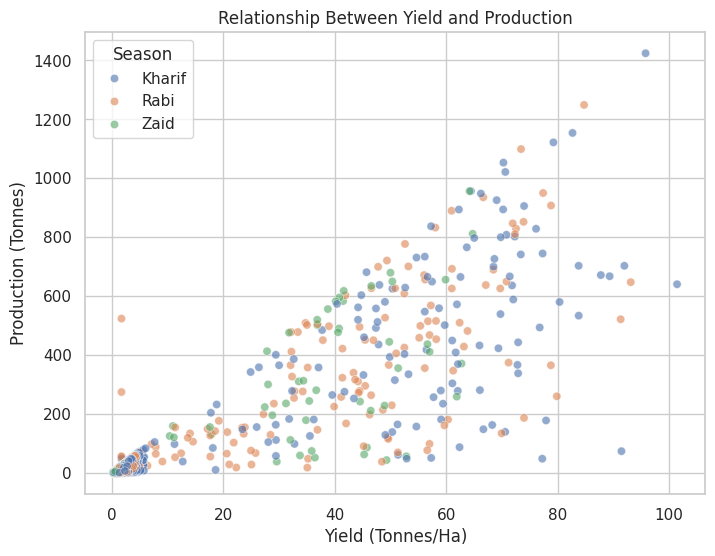

In [47]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_clean,
    x='Yield_Tonnes_Ha',
    y='Production_Tonnes',
    hue='Season',
    alpha=0.6
)

plt.title('Relationship Between Yield and Production')
plt.xlabel('Yield (Tonnes/Ha)')
plt.ylabel('Production (Tonnes)')

plt.show()

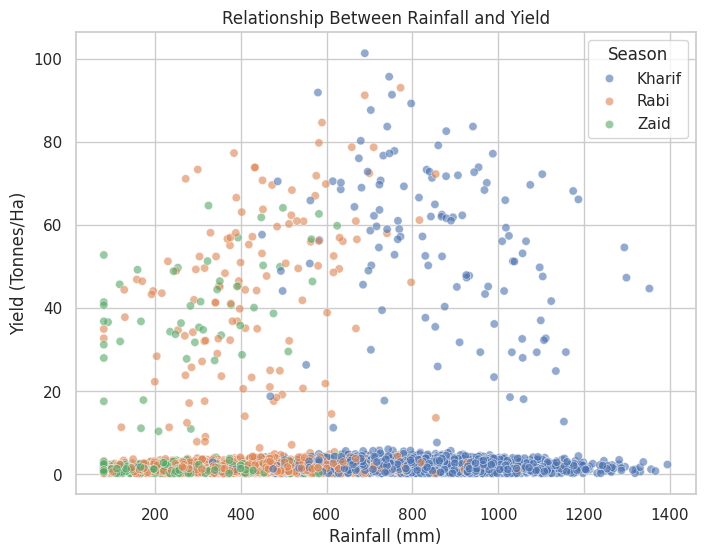

In [48]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_clean,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season',
    alpha=0.6
)

plt.title('Relationship Between Rainfall and Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

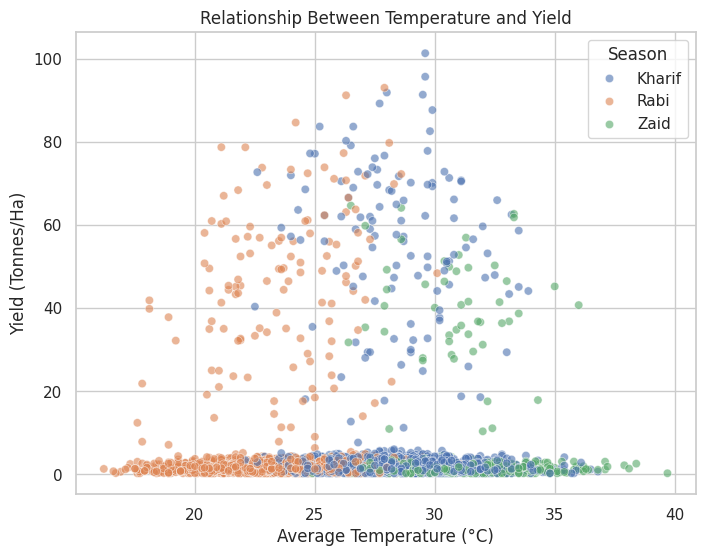

In [49]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_clean,
    x='Avg_Temperature_C',
    y='Yield_Tonnes_Ha',
    hue='Season',
    alpha=0.6
)

plt.title('Relationship Between Temperature and Yield')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

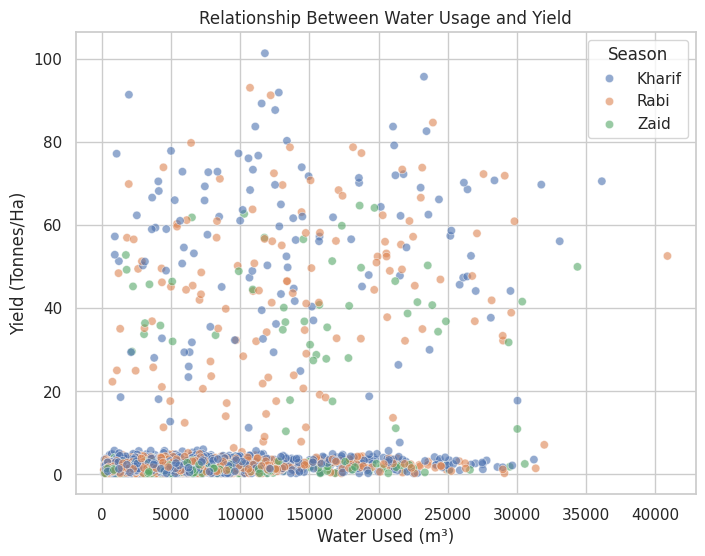

In [50]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_clean,
    x='Water_Used_m3',
    y='Yield_Tonnes_Ha',
    hue='Season',
    alpha=0.6
)

plt.title('Relationship Between Water Usage and Yield')
plt.xlabel('Water Used (m³)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

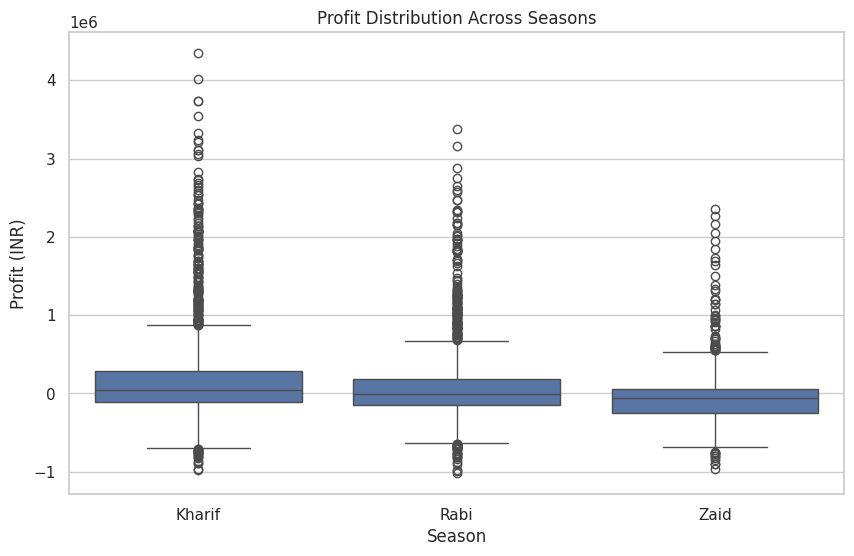

In [51]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_clean,
    x='Season',
    y='Profit_INR'
)

plt.title('Profit Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Profit (INR)')

plt.show()

In [52]:
df_clean['Profit_Status'] = np.where(
    df_clean['Profit_INR'] >= 0,
    'Profitable',
    'Loss'
)

profit_status = pd.crosstab(
    df_clean['Season'],
    df_clean['Profit_Status']
)

display(profit_status)

Profit_Status,Loss,Profitable
Season,,
Kharif,751,1028
Rabi,832,795
Zaid,383,211


In [53]:
profit_percentage = pd.crosstab(
    df_clean['Season'],
    df_clean['Profit_Status'],
    normalize='index'
) * 100

display(profit_percentage.round(2))

Profit_Status,Loss,Profitable
Season,,
Kharif,42.21,57.79
Rabi,51.14,48.86
Zaid,64.48,35.52


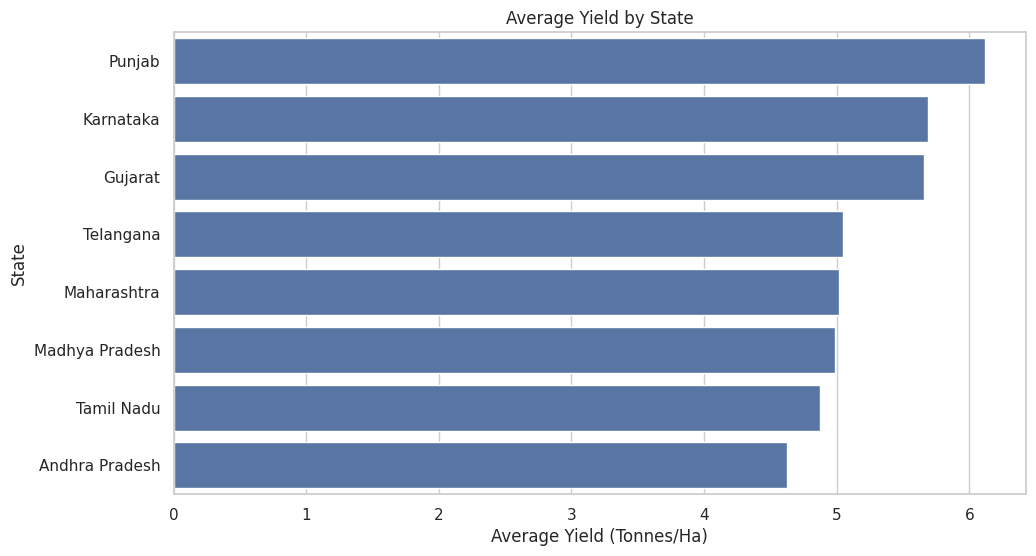

In [54]:
state_yield = df_clean.groupby(
    'State'
)['Yield_Tonnes_Ha'].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(11,6))

sns.barplot(
    x=state_yield.values,
    y=state_yield.index
)

plt.title('Average Yield by State')
plt.xlabel('Average Yield (Tonnes/Ha)')
plt.ylabel('State')

plt.show()

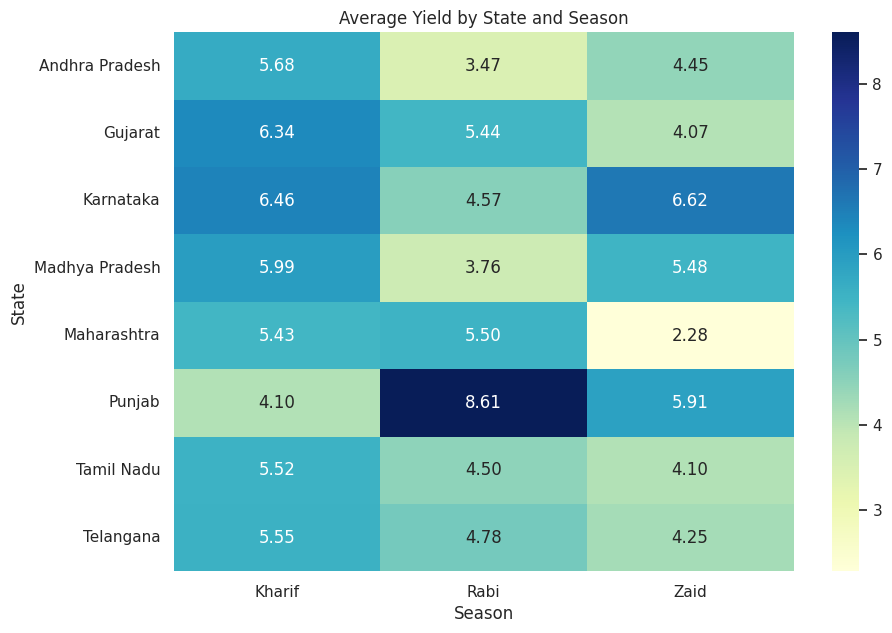

In [55]:
state_season_yield = pd.pivot_table(
    df_clean,
    values='Yield_Tonnes_Ha',
    index='State',
    columns='Season',
    aggfunc='mean'
)

plt.figure(figsize=(10,7))

sns.heatmap(
    state_season_yield,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Average Yield by State and Season')
plt.xlabel('Season')
plt.ylabel('State')

plt.show()

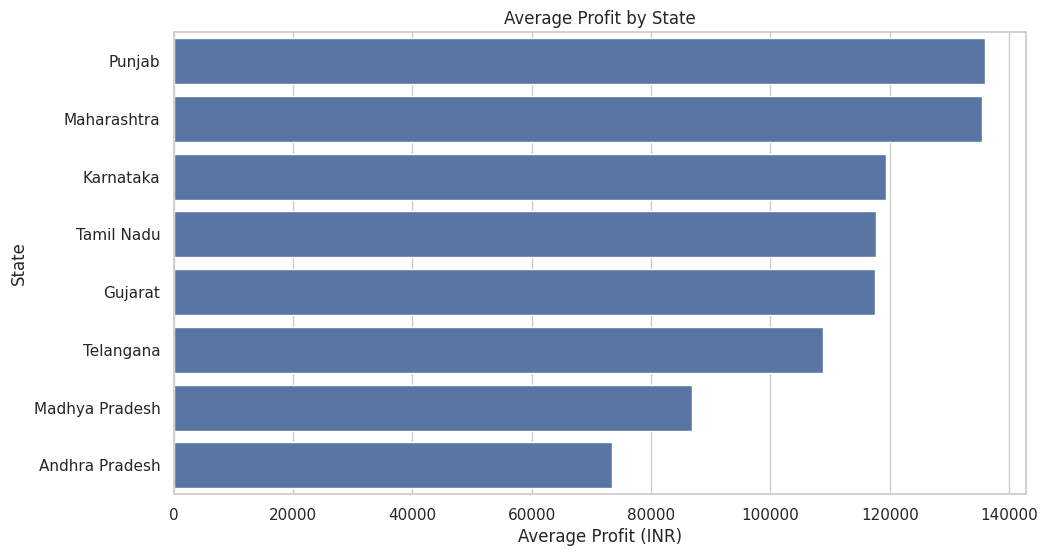

In [56]:
state_profit = df_clean.groupby(
    'State'
)['Profit_INR'].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(11,6))

sns.barplot(
    x=state_profit.values,
    y=state_profit.index
)

plt.title('Average Profit by State')
plt.xlabel('Average Profit (INR)')
plt.ylabel('State')

plt.show()

In [57]:
Q1 = df_clean['Yield_Tonnes_Ha'].quantile(0.25)
Q3 = df_clean['Yield_Tonnes_Ha'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

yield_outliers = df_clean[
    (df_clean['Yield_Tonnes_Ha'] < lower_bound) |
    (df_clean['Yield_Tonnes_Ha'] > upper_bound)
]

print("Number of yield outliers:", len(yield_outliers))

display(
    yield_outliers[
        [
            'Farm_ID',
            'State',
            'Crop',
            'Season',
            'Yield_Tonnes_Ha',
            'Production_Tonnes',
            'Profit_INR'
        ]
    ].head(20)
)

Number of yield outliers: 302


,Farm_ID,State,Crop,Season,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR
47,SF10048,Punjab,Sugarcane,Zaid,36.69,281.78,556688
75,SF10076,Maharashtra,Sugarcane,Kharif,62.58,665.85,1675730
79,SF10080,Karnataka,Sugarcane,Zaid,33.55,311.68,691166
82,SF10083,Andhra Pradesh,Sugarcane,Rabi,49.52,121.82,279221
92,SF10093,Gujarat,Sugarcane,Kharif,70.23,894.73,2427692
113,SF10114,Tamil Nadu,Sugarcane,Rabi,58.06,833.16,2324331
132,SF10133,Telangana,Sugarcane,Kharif,29.47,112.87,89113
154,SF10155,Telangana,Sugarcane,Kharif,47.88,436.67,798280
155,SF10156,Madhya Pradesh,Sugarcane,Kharif,62.09,279.41,573019
164,SF10165,Telangana,Sugarcane,Rabi,36.91,147.64,297233


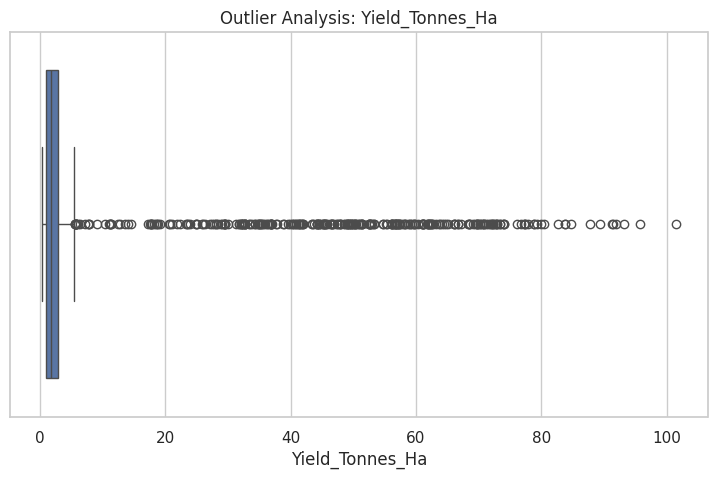

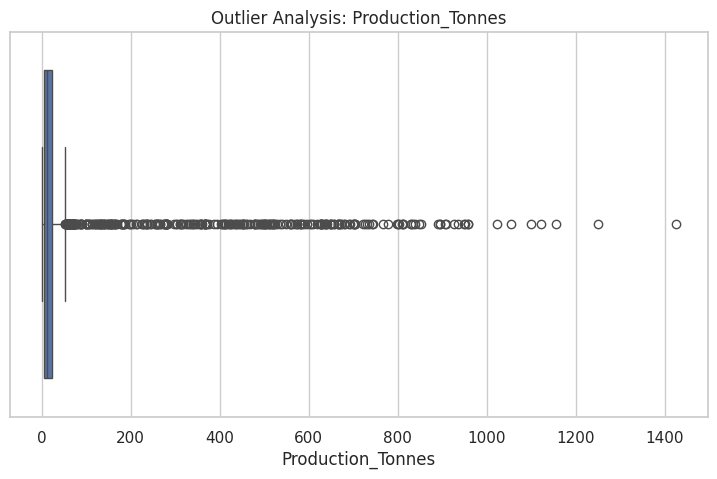

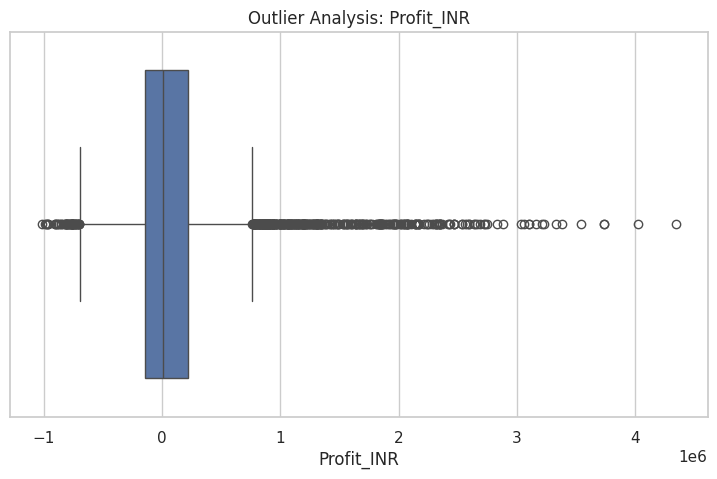

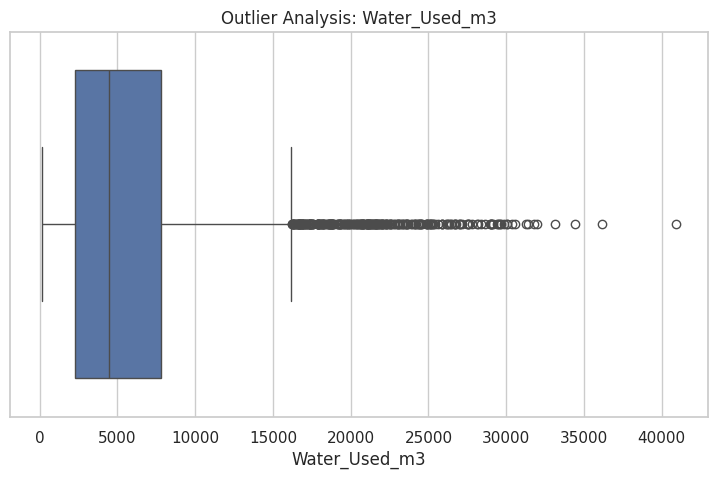

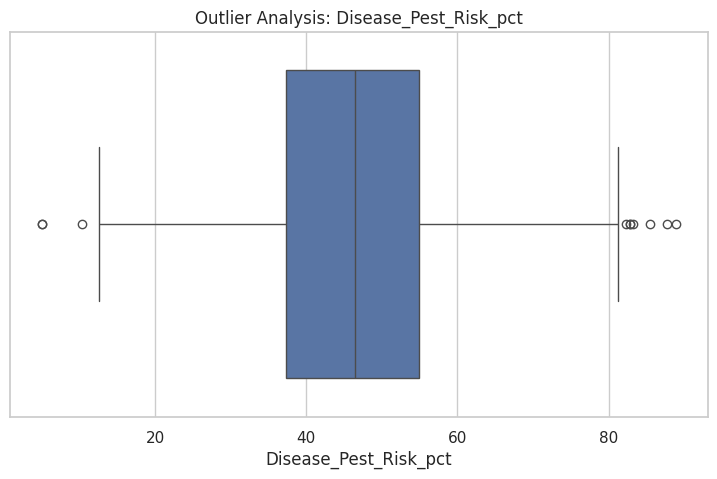

In [58]:
important_variables = [
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Profit_INR',
    'Water_Used_m3',
    'Disease_Pest_Risk_pct'
]

for column in important_variables:

    plt.figure(figsize=(9,5))

    sns.boxplot(
        x=df_clean[column]
    )

    plt.title(f'Outlier Analysis: {column}')
    plt.xlabel(column)

    plt.show()

In [59]:
kharif_yield = df_clean[
    df_clean['Season'] == 'Kharif'
]['Yield_Tonnes_Ha']

rabi_yield = df_clean[
    df_clean['Season'] == 'Rabi'
]['Yield_Tonnes_Ha']

zaid_yield = df_clean[
    df_clean['Season'] == 'Zaid'
]['Yield_Tonnes_Ha']

anova_result = f_oneway(
    kharif_yield,
    rabi_yield,
    zaid_yield
)

print("ANOVA Result")
print("----------------------")
print("F-statistic:", anova_result.statistic)
print("P-value:", anova_result.pvalue)

if anova_result.pvalue < 0.05:
    print("\nConclusion:")
    print("There is a statistically significant difference in yield between seasons.")
else:
    print("\nConclusion:")
    print("There is no statistically significant difference in yield between seasons.")

ANOVA Result
----------------------
F-statistic: 1.5438804542488311
P-value: 0.21367813841792296

Conclusion:
There is no statistically significant difference in yield between seasons.


In [60]:
kharif_profit = df_clean[
    df_clean['Season'] == 'Kharif'
]['Profit_INR']

rabi_profit = df_clean[
    df_clean['Season'] == 'Rabi'
]['Profit_INR']

zaid_profit = df_clean[
    df_clean['Season'] == 'Zaid'
]['Profit_INR']

profit_anova = f_oneway(
    kharif_profit,
    rabi_profit,
    zaid_profit
)

print("Profit ANOVA")
print("----------------------")
print("F-statistic:", profit_anova.statistic)
print("P-value:", profit_anova.pvalue)

if profit_anova.pvalue < 0.05:
    print("\nConclusion:")
    print("Season has a statistically significant association with differences in average profit.")
else:
    print("\nConclusion:")
    print("No statistically significant difference in average profit was detected.")

Profit ANOVA
----------------------
F-statistic: 34.29175033935195
P-value: 1.7124156677360182e-15

Conclusion:
Season has a statistically significant association with differences in average profit.


In [61]:
kruskal_result = kruskal(
    kharif_yield,
    rabi_yield,
    zaid_yield
)

print("Kruskal-Wallis Test")
print("----------------------")
print("Statistic:", kruskal_result.statistic)
print("P-value:", kruskal_result.pvalue)

if kruskal_result.pvalue < 0.05:
    print("\nConclusion:")
    print("The distributions of yield differ significantly across seasons.")
else:
    print("\nConclusion:")
    print("No statistically significant difference in yield distributions was detected.")

Kruskal-Wallis Test
----------------------
Statistic: 68.71306722231378
P-value: 1.1999054760748268e-15

Conclusion:
The distributions of yield differ significantly across seasons.


In [62]:
target = 'Yield_Tonnes_Ha'

correlations = df_clean.select_dtypes(
    include=np.number
).corr()[target].sort_values(
    ascending=False
)

print("Variables most positively correlated with Yield:")
display(
    correlations.head(10).to_frame(
        'Correlation'
    )
)

print("\nVariables most negatively correlated with Yield:")
display(
    correlations.tail(10).to_frame(
        'Correlation'
    )
)

Variables most positively correlated with Yield:


,Correlation
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.912568
Production_Tonnes,0.882813
Revenue_per_Hectare,0.542074
Profit_per_Hectare,0.535367
Profit_INR,0.488466
Revenue_INR,0.432152
Water_Used_m3,0.386294
Profit_Margin_pct,0.204993
Nitrogen_kg_ha,0.053149



Variables most negatively correlated with Yield:


,Correlation
Soil_Moisture_pct,0.010999
Avg_Temperature_C,0.009996
Potassium_kg_ha,0.003382
Cost_per_Hectare,0.003231
Fertilizer_kg_ha,0.000018
Seed_Quality_Score,-0.007209
Pesticide_Litre_ha,-0.007779
Sunlight_Hours_Day,-0.015341
Soil_pH,-0.020672
Market_Price_INR_Tonne,-0.382607


In [63]:
variables = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Water_Used_m3',
    'Disease_Pest_Risk_pct'
]

results = []

for variable in variables:

    r, p = pearsonr(
        df_clean[variable],
        df_clean['Yield_Tonnes_Ha']
    )

    results.append({
        'Variable': variable,
        'Pearson_r': r,
        'P_value': p
    })

correlation_tests = pd.DataFrame(results)

correlation_tests['Significant'] = np.where(
    correlation_tests['P_value'] < 0.05,
    'Yes',
    'No'
)

correlation_tests = correlation_tests.sort_values(
    'Pearson_r',
    ascending=False
)

display(correlation_tests)

,Variable,Pearson_r,P_value,Significant
11,Water_Used_m3,0.386294,1.641403e-142,Yes
5,Nitrogen_kg_ha,0.053149,7.716829e-04,Yes
6,Phosphorus_kg_ha,0.047941,2.422584e-03,Yes
0,Rainfall_mm,0.030951,5.030401e-02,No
12,Disease_Pest_Risk_pct,0.014292,3.661851e-01,No
2,Humidity_pct,0.012297,4.368374e-01,No
4,Soil_Moisture_pct,0.010999,4.867650e-01,No
1,Avg_Temperature_C,0.009996,5.273601e-01,No
7,Potassium_kg_ha,0.003382,8.306634e-01,No
8,Fertilizer_kg_ha,0.000018,9.991064e-01,No


In [64]:
season_metrics = df_clean.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
}).round(2)

display(season_metrics)

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,
Kharif,5.63,46.31,710719.06,178914.65,5.89,54.47
Rabi,5.04,41.49,601526.05,87689.47,5.19,40.48
Zaid,4.64,38.89,519171.90,-24804.82,4.41,38.22


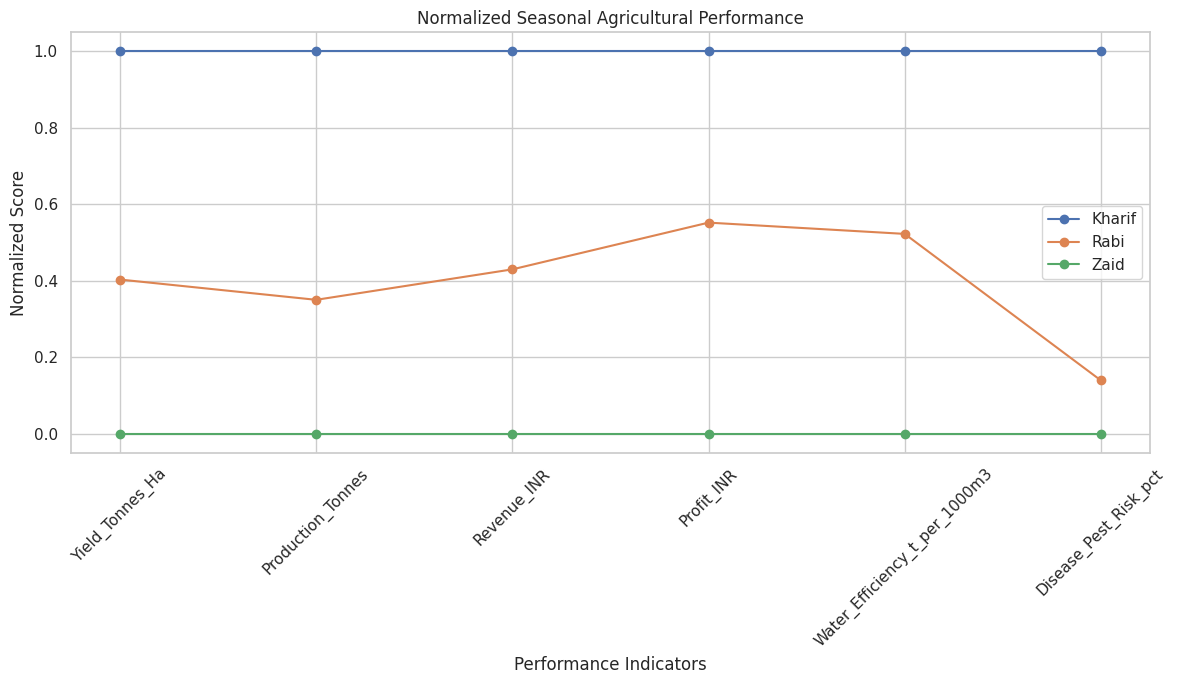

In [65]:
from sklearn.preprocessing import MinMaxScaler

metrics_for_comparison = [
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Revenue_INR',
    'Profit_INR',
    'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct'
]

season_data = df_clean.groupby(
    'Season'
)[metrics_for_comparison].mean()

scaler = MinMaxScaler()

normalized_data = pd.DataFrame(
    scaler.fit_transform(season_data),
    index=season_data.index,
    columns=season_data.columns
)

plt.figure(figsize=(12,7))

for season in normalized_data.index:
    plt.plot(
        normalized_data.columns,
        normalized_data.loc[season],
        marker='o',
        label=season
    )

plt.title('Normalized Seasonal Agricultural Performance')
plt.xlabel('Performance Indicators')
plt.ylabel('Normalized Score')

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()
plt.show()

In [66]:
season_means = df_clean.groupby('Season').agg({

    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'

})

print("BEST SEASON BY METRIC")
print("="*60)

for column in season_means.columns:

    if column == 'Disease_Pest_Risk_pct':
        best = season_means[column].idxmin()
        direction = "lowest risk"
    else:
        best = season_means[column].idxmax()
        direction = "highest value"

    print(
        f"{column}: {best} ({direction})"
    )

BEST SEASON BY METRIC
Yield_Tonnes_Ha: Kharif (highest value)
Production_Tonnes: Kharif (highest value)
Revenue_INR: Kharif (highest value)
Profit_INR: Kharif (highest value)
Water_Efficiency_t_per_1000m3: Kharif (highest value)
Disease_Pest_Risk_pct: Zaid (lowest risk)


In [67]:
best_crop_yield = (
    df_clean.groupby('Crop')['Yield_Tonnes_Ha']
    .mean()
    .sort_values(ascending=False)
)

print("Highest average-yield crop:")
print(
    best_crop_yield.index[0],
    "->",
    round(best_crop_yield.iloc[0], 2),
    "Tonnes/Ha"
)

Highest average-yield crop:
Sugarcane -> 46.64 Tonnes/Ha


In [68]:
best_irrigation = (
    df_clean.groupby('Irrigation_Method')
    .agg({
        'Yield_Tonnes_Ha': 'mean',
        'Profit_INR': 'mean',
        'Water_Efficiency_t_per_1000m3': 'mean'
    })
    .sort_values(
        'Profit_INR',
        ascending=False
    )
)

display(best_irrigation)

print(
    "Highest average profit irrigation method:",
    best_irrigation.index[0]
)

,Yield_Tonnes_Ha,Profit_INR,Water_Efficiency_t_per_1000m3
Irrigation_Method,,,
Drip,6.577989,219625.997814,6.267129
Sprinkler,5.160627,91121.079019,4.669805
Rainfed,4.602142,79050.365034,7.563784
Flood,4.863977,73354.022901,3.438853


Highest average profit irrigation method: Drip


In [69]:
# Identify extremely high yield farms

high_yield_threshold = df_clean[
    'Yield_Tonnes_Ha'
].quantile(0.99)

high_yield_farms = df_clean[
    df_clean['Yield_Tonnes_Ha'] >= high_yield_threshold
]

print(
    "99th percentile yield threshold:",
    round(high_yield_threshold, 2)
)

print(
    "Number of extremely high-yield farms:",
    len(high_yield_farms)
)

display(
    high_yield_farms[
        [
            'Farm_ID',
            'State',
            'District',
            'Crop',
            'Season',
            'Yield_Tonnes_Ha',
            'Production_Tonnes',
            'Profit_INR'
        ]
    ]
)

99th percentile yield threshold: 70.82
Number of extremely high-yield farms: 40


,Farm_ID,State,District,Crop,Season,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR
222,SF10223,Maharashtra,Nashik,Sugarcane,Rabi,72.54,829.86,2578433
298,SF10299,Punjab,Erode,Sugarcane,Kharif,71.83,637.13,1528473
357,SF10358,Punjab,Warangal,Sugarcane,Rabi,84.75,1249.21,3378879
644,SF10645,Andhra Pradesh,Ludhiana,Sugarcane,Kharif,89.34,668.26,1984818
811,SF10812,Telangana,Nashik,Sugarcane,Kharif,83.78,703.75,2298743
862,SF10863,Maharashtra,Raichur,Sugarcane,Rabi,77.40,950.47,2348023
1006,SF11007,Gujarat,Raichur,Sugarcane,Rabi,71.95,847.57,2174999
1178,SF11179,Karnataka,Nalgonda,Sugarcane,Kharif,83.79,534.58,1200815
1197,SF11198,Karnataka,Rajkot,Sugarcane,Kharif,72.05,589.37,1690869
1217,SF11218,Andhra Pradesh,Guntur,Sugarcane,Rabi,73.89,852.69,1953811


In [70]:
loss_making = df_clean[
    df_clean['Profit_INR'] < 0
]

print(
    "Number of loss-making farms:",
    len(loss_making)
)

print(
    "Percentage of loss-making farms:",
    round(
        len(loss_making) /
        len(df_clean) * 100,
        2
    ),
    "%"
)

Number of loss-making farms: 1966
Percentage of loss-making farms: 49.15 %


In [71]:
loss_by_season = df_clean.groupby(
    'Season'
).apply(
    lambda x: (x['Profit_INR'] < 0).mean() * 100
)

loss_by_season = loss_by_season.sort_values(
    ascending=False
)

print("Percentage of loss-making farms by season:")
display(
    loss_by_season.round(2).to_frame(
        'Loss-making Farms (%)'
    )
)

Percentage of loss-making farms by season:


,Loss-making Farms (%)
Season,
Zaid,64.48
Rabi,51.14
Kharif,42.21


In [72]:
final_summary = df_clean.groupby('Season').agg({

    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Profit_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'

}).round(2)

final_summary.columns = [
    'Avg Yield',
    'Avg Production',
    'Avg Revenue',
    'Avg Cost',
    'Avg Profit',
    'Avg Water Used',
    'Water Efficiency',
    'Disease/Pest Risk'
]

display(final_summary)

,Avg Yield,Avg Production,Avg Revenue,Avg Cost,Avg Profit,Avg Water Used,Water Efficiency,Disease/Pest Risk
Season,,,,,,,,
Kharif,5.63,46.31,710719.06,531804.41,178914.65,6102.20,5.89,54.47
Rabi,5.04,41.49,601526.05,513836.58,87689.47,5846.99,5.19,40.48
Zaid,4.64,38.89,519171.90,543976.73,-24804.82,6419.89,4.41,38.22


In [73]:
best_yield_season = season_means[
    'Yield_Tonnes_Ha'
].idxmax()

best_profit_season = season_means[
    'Profit_INR'
].idxmax()

best_revenue_season = season_means[
    'Revenue_INR'
].idxmax()

best_water_efficiency = season_means[
    'Water_Efficiency_t_per_1000m3'
].idxmax()

lowest_risk_season = season_means[
    'Disease_Pest_Risk_pct'
].idxmin()

print("="*70)
print("KEY PROJECT FINDINGS")
print("="*70)

print(
    f"1. Highest average yield: {best_yield_season}"
)

print(
    f"2. Highest average profit: {best_profit_season}"
)

print(
    f"3. Highest average revenue: {best_revenue_season}"
)

print(
    f"4. Highest water efficiency: {best_water_efficiency}"
)

print(
    f"5. Lowest disease/pest risk: {lowest_risk_season}"
)

print("="*70)

KEY PROJECT FINDINGS
1. Highest average yield: Kharif
2. Highest average profit: Kharif
3. Highest average revenue: Kharif
4. Highest water efficiency: Kharif
5. Lowest disease/pest risk: Zaid


# Recommendations

Based on the analysis, the following recommendations can be made:

### 1. Seasonal Planning
Agricultural planning should account for differences in rainfall,
temperature, water availability, disease risk and economic performance
across Kharif, Rabi and Zaid seasons.

### 2. Improve Water Management
Water efficiency should be considered along with yield. Irrigation
decisions should focus not only on increasing production but also on
using water efficiently.

### 3. Crop-Specific Planning
Crop performance varies across seasons. Farmers and agricultural
planners should consider crop-season combinations instead of applying
the same strategy to every crop.

### 4. Monitor Input Costs
High production does not necessarily guarantee high profitability.
Fertilizer, pesticide, irrigation and other input costs should be
considered when evaluating agricultural performance.

### 5. Disease and Pest Management
Seasonal disease and pest risk should be incorporated into agricultural
planning so that preventive measures can be planned before high-risk
periods.

### 6. Regional Planning
Since agricultural performance can vary between states and regions,
local environmental and agricultural conditions should be considered
when developing seasonal strategies.

### 7. Data-Driven Decision Making
Agricultural decisions should use multiple indicators such as yield,
profit, water efficiency, environmental conditions and disease risk
rather than relying on a single performance measure.

# Conclusion

The Seasonal Agriculture Performance Analysis project examined
agricultural activities across Kharif, Rabi and Zaid seasons using
statistical analysis and data visualization techniques.

The analysis considered agricultural productivity, production,
revenue, costs, profit, water usage, water efficiency, environmental
conditions, irrigation methods, crop characteristics and disease/pest
risk.

The results indicate that agricultural performance varies across
seasons and that the nature of these variations differs depending on
the performance indicator being considered.

Kharif recorded the highest average yield, revenue, profit and water
efficiency among the three seasons in the analyzed dataset. Zaid
showed comparatively lower average profit and water efficiency and a
larger proportion of loss-making farms.

However, the statistical analysis showed that the difference in mean
yield between seasons was not statistically significant at the 5%
level. In contrast, the differences in average profit across seasons
were statistically significant.

The analysis also identified relationships between agricultural
outcomes and variables such as production, water usage, environmental
conditions and resource usage. These relationships should be
interpreted as associations rather than direct evidence of causation.

Overall, the project demonstrates how data analytics can transform
raw agricultural data into useful insights for seasonal planning,
resource management, crop selection, risk management and
profitability analysis.